# Results Synthesis

## Objective
This final notebook pulls the main outputs together in one place so I can see what belongs in the written report and what language needs to stay cautious. If I only had a short meeting to explain the study, these are the figures, tables, and caveats I would bring first.


## Notebook Purpose

This notebook packages the final evidence into dissertation-ready claims, tables, and figure references. It is the bridge between experimental notebooks and the written report or live defence.


## Why This Matters

A defence needs concise, well-scoped claims. This notebook gathers the strongest results and the necessary caveats so the project can be explained without overstating the synthetic fusion branch.


## Load Key Result Tables

This setup cell reads the main result tables from previous notebooks and displays compact previews. It confirms that the final synthesis is based on saved artifacts rather than hidden notebook state.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from IPython.display import Image, display

key_tables = {
    'breakhis_patient_metrics': pd.read_csv(METRICS / 'breakhis_patient_level_metrics.csv'),
    'fusion_summary': pd.read_csv(METRICS / 'synthetic_fusion_summary.csv'),
    'joint_comparison': pd.read_csv(METRICS / 'joint_model_comparison.csv'),
}
for name, frame in key_tables.items():
    print(f'\n{name}')
    display(frame.head(10))


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs

breakhis_patient_metrics


,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece
0,0.769231,0.875,0.777778,0.823529,0.888889,0.149788,0.234854



fusion_summary


,pairing_type,experiment,metric,mean,std,min,max
0,random,early_fusion,accuracy,0.970175,0.010002,0.956140,0.982456
1,random,early_fusion,brier_score,0.022838,0.009095,0.014408,0.033308
2,random,early_fusion,f1_score,0.959143,0.013240,0.941176,0.975610
3,random,early_fusion,precision,0.971290,0.025303,0.930233,1.000000
4,random,early_fusion,recall,0.947619,0.010648,0.928571,0.952381
5,random,early_fusion,roc_auc,0.994775,0.004828,0.988757,0.999339
6,random,image_only,accuracy,0.585965,0.036905,0.526316,0.622807
7,random,image_only,brier_score,0.262869,0.017066,0.245995,0.289266
8,random,image_only,f1_score,0.346602,0.073730,0.228571,0.426667
9,random,image_only,precision,0.411399,0.076043,0.285714,0.484848



joint_comparison


,family,model,accuracy,roc_auc,calibration_or_stability,claim_type
0,monomodel,BreaKHis corrected patient-level model,0.769231,0.888889,ECE=0.235,main new image result
1,monomodel,Wisconsin published branch,0.960000,0.997000,MC Dropout reported in source notebook,published Wisconsin branch
2,synthetic_fusion,random | early_fusion,0.970175,0.994775,std_acc=0.010,exploratory only
3,synthetic_fusion,random | late_fusion,0.971930,0.990410,std_acc=0.010,exploratory only
4,synthetic_fusion,same_label | early_fusion,1.000000,1.000000,std_acc=0.000,exploratory only


## Record Study Claims

This cell writes the claim set that should guide the dissertation narrative. Claims are labelled as supported or exploratory so the final argument stays honest.


In [2]:
study_claims = pd.DataFrame(
    [
        {'claim_type': 'Supported in this study', 'statement': 'Patient-level splitting is necessary on BreaKHis because image-level splitting leaks patients across subsets.'},
        {'claim_type': 'Supported in this study', 'statement': 'The corrected BreaKHis result is lower than the earlier leaked result but substantially more trustworthy.'},
        {'claim_type': 'Supported in this study', 'statement': 'The Wisconsin branch is a published Wisconsin comparator rather than newly re-optimised work.'},
        {'claim_type': 'Exploratory only', 'statement': 'Synthetic same-label fusion can improve metrics, but those gains may reflect artificial label alignment rather than genuine multimodal complementarity.'},
        {'claim_type': 'Exploratory only', 'statement': 'Random-pairing controls are essential for interpreting synthetic multimodal experiments.'},
    ]
)
study_claims.to_csv(REPORTS / 'study_claims.csv', index=False)
study_claims


,claim_type,statement
0,Supported in this study,Patient-level splitting is necessary on BreaKH...
1,Supported in this study,The corrected BreaKHis result is lower than th...
2,Supported in this study,The Wisconsin branch is a published Wisconsin com...
3,Exploratory only,Synthetic same-label fusion can improve metric...
4,Exploratory only,Random-pairing controls are essential for inte...


## Build Figure Manifest

This cell lists the most useful figures and where they belong in the dissertation. The manifest helps keep final writing and presentation preparation organized.


In [3]:
figure_manifest = pd.DataFrame(
    [
        {'figure_path': str(FIGURES / 'breakhis_sample_mosaic.png'), 'suggested_use': 'Dataset chapter or exploratory analysis section'},
        {'figure_path': str(FIGURES / 'breakhis_leakage_audit.png'), 'suggested_use': 'Methods chapter to justify patient-level splitting'},
        {'figure_path': str(FIGURES / 'breakhis_model_development_comparison.png'), 'suggested_use': 'Model development section'},
        {'figure_path': str(FIGURES / 'breakhis_patient_confusion_matrix.png'), 'suggested_use': 'Results chapter'},
        {'figure_path': str(FIGURES / 'breakhis_patient_roc_curve.png'), 'suggested_use': 'Results chapter'},
        {'figure_path': str(FIGURES / 'breakhis_patient_calibration.png'), 'suggested_use': 'Results or discussion chapter'},
        {'figure_path': str(FIGURES / 'fusion_experiment_comparison.png'), 'suggested_use': 'Exploratory fusion section'},
        {'figure_path': str(FIGURES / 'joint_model_accuracy_comparison.png'), 'suggested_use': 'Comparison/discussion chapter'},
    ]
)
figure_manifest.to_csv(REPORTS / 'figure_manifest.csv', index=False)
figure_manifest


,figure_path,suggested_use
0,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Dataset chapter or exploratory analysis section
1,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Methods chapter to justify patient-level split...
2,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Model development section
3,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Results chapter
4,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Results chapter
5,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Results or discussion chapter
6,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Exploratory fusion section
7,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Comparison/discussion chapter


## Display Defence Figures

This cell displays a small set of high-value figures for presentation review. These figures cover leakage, image-model evaluation, fusion comparison, and joint model comparison.



Showing breakhis_leakage_audit.png


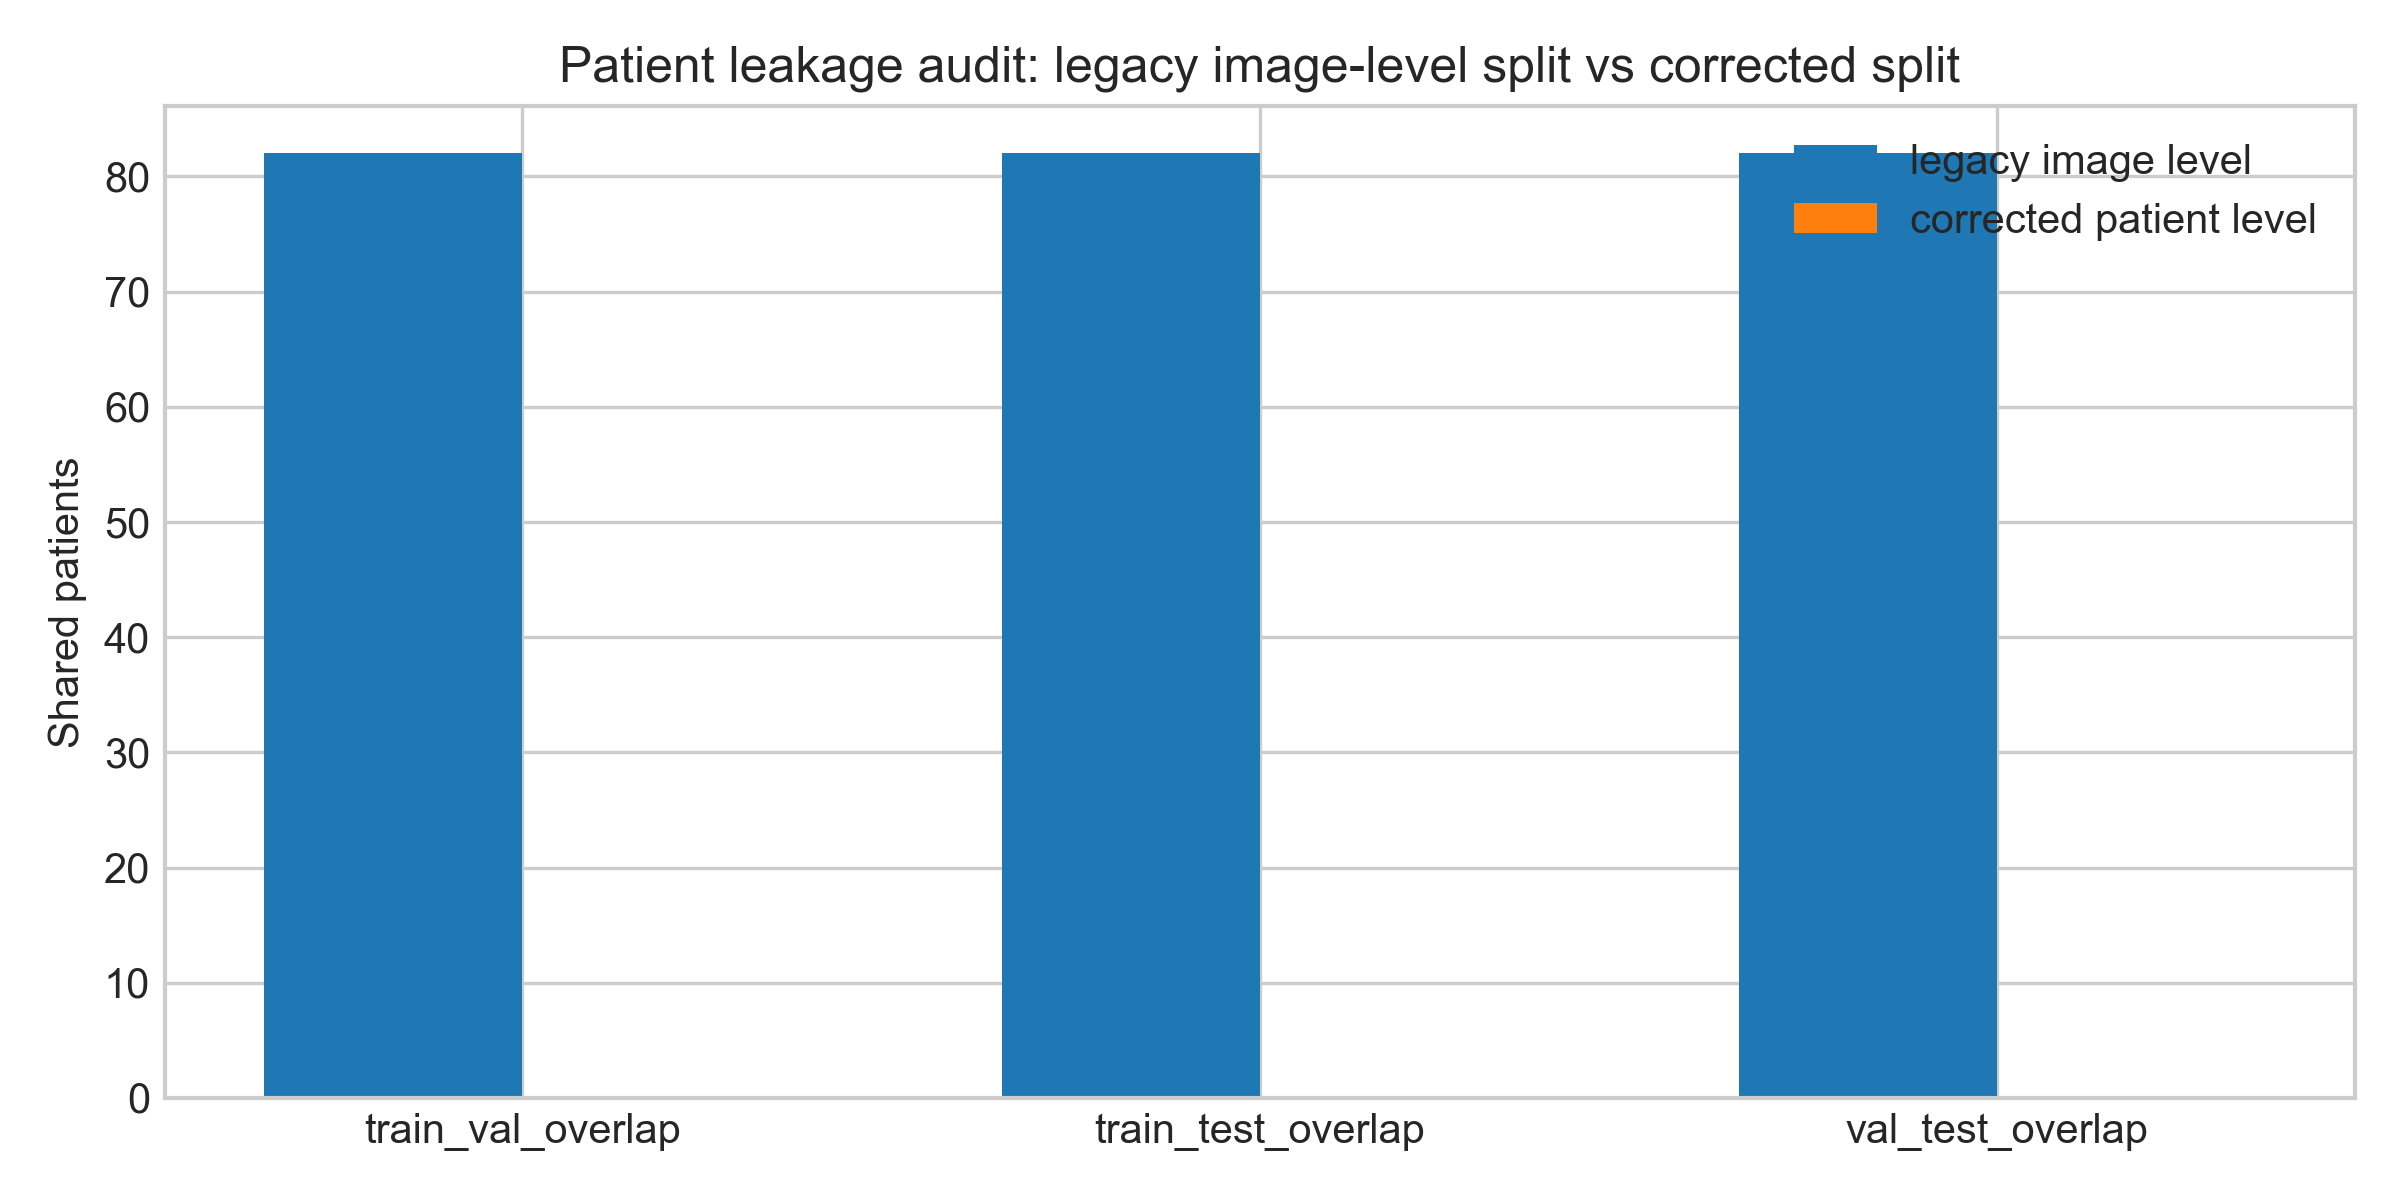


Showing breakhis_patient_confusion_matrix.png


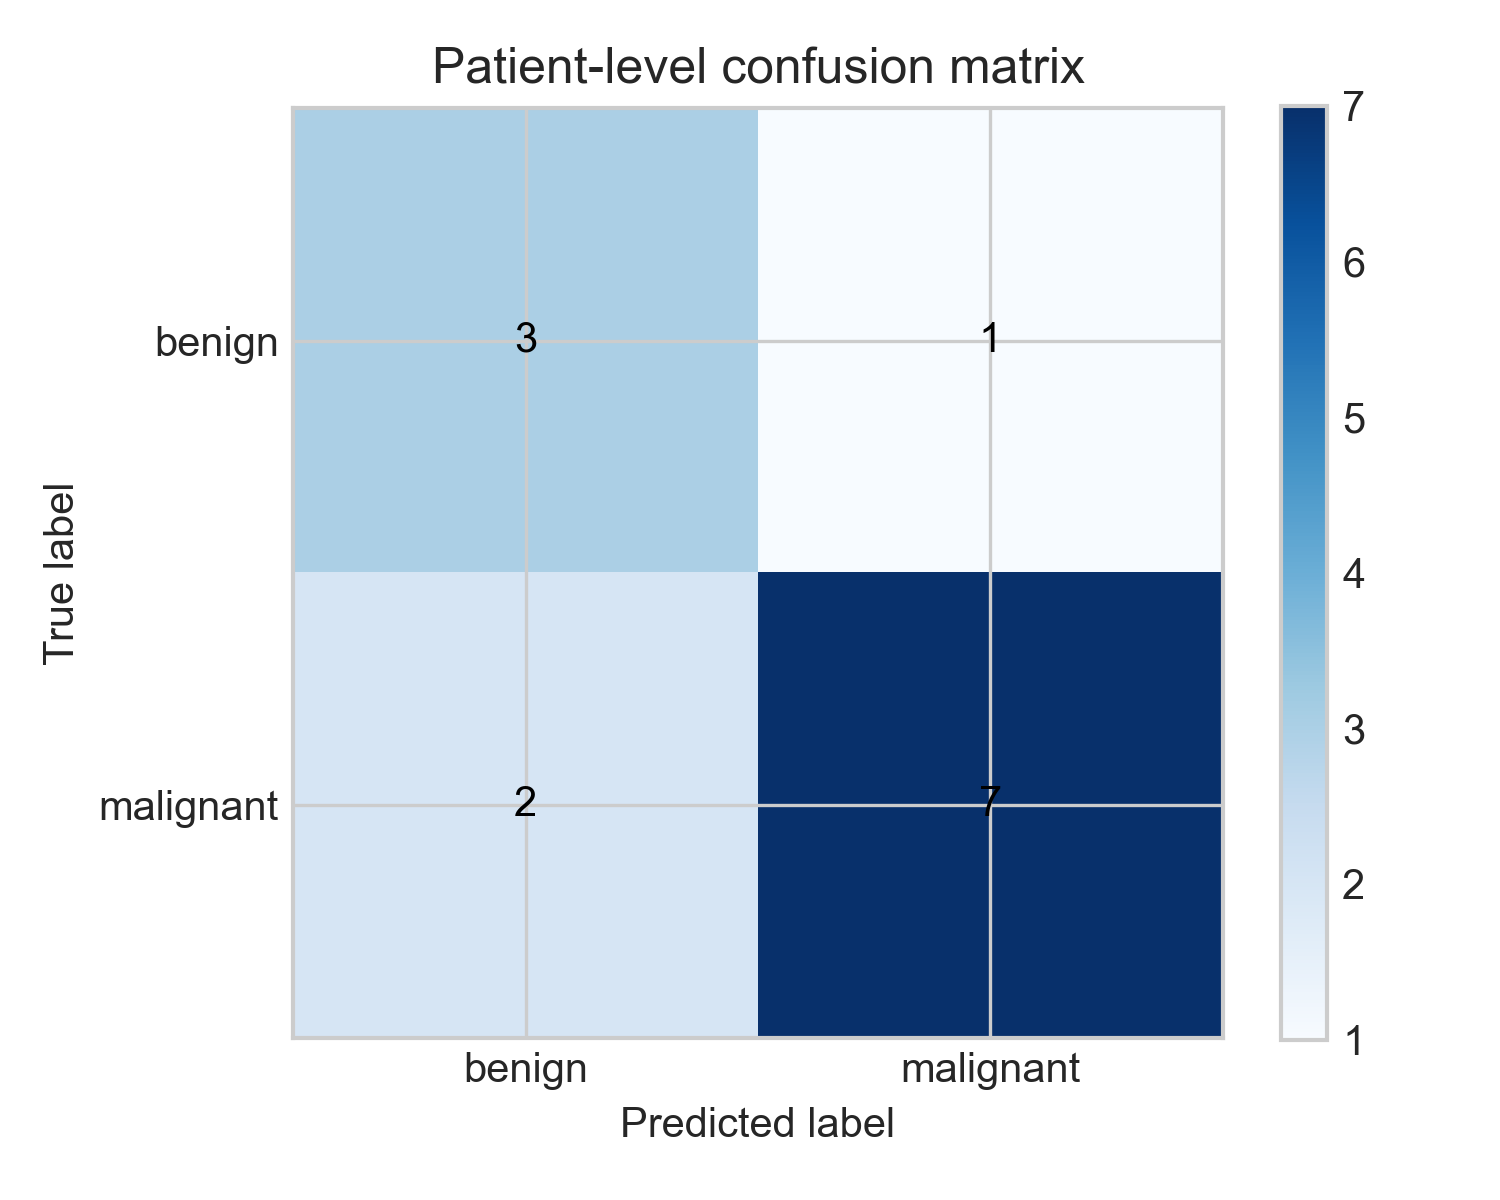


Showing fusion_experiment_comparison.png


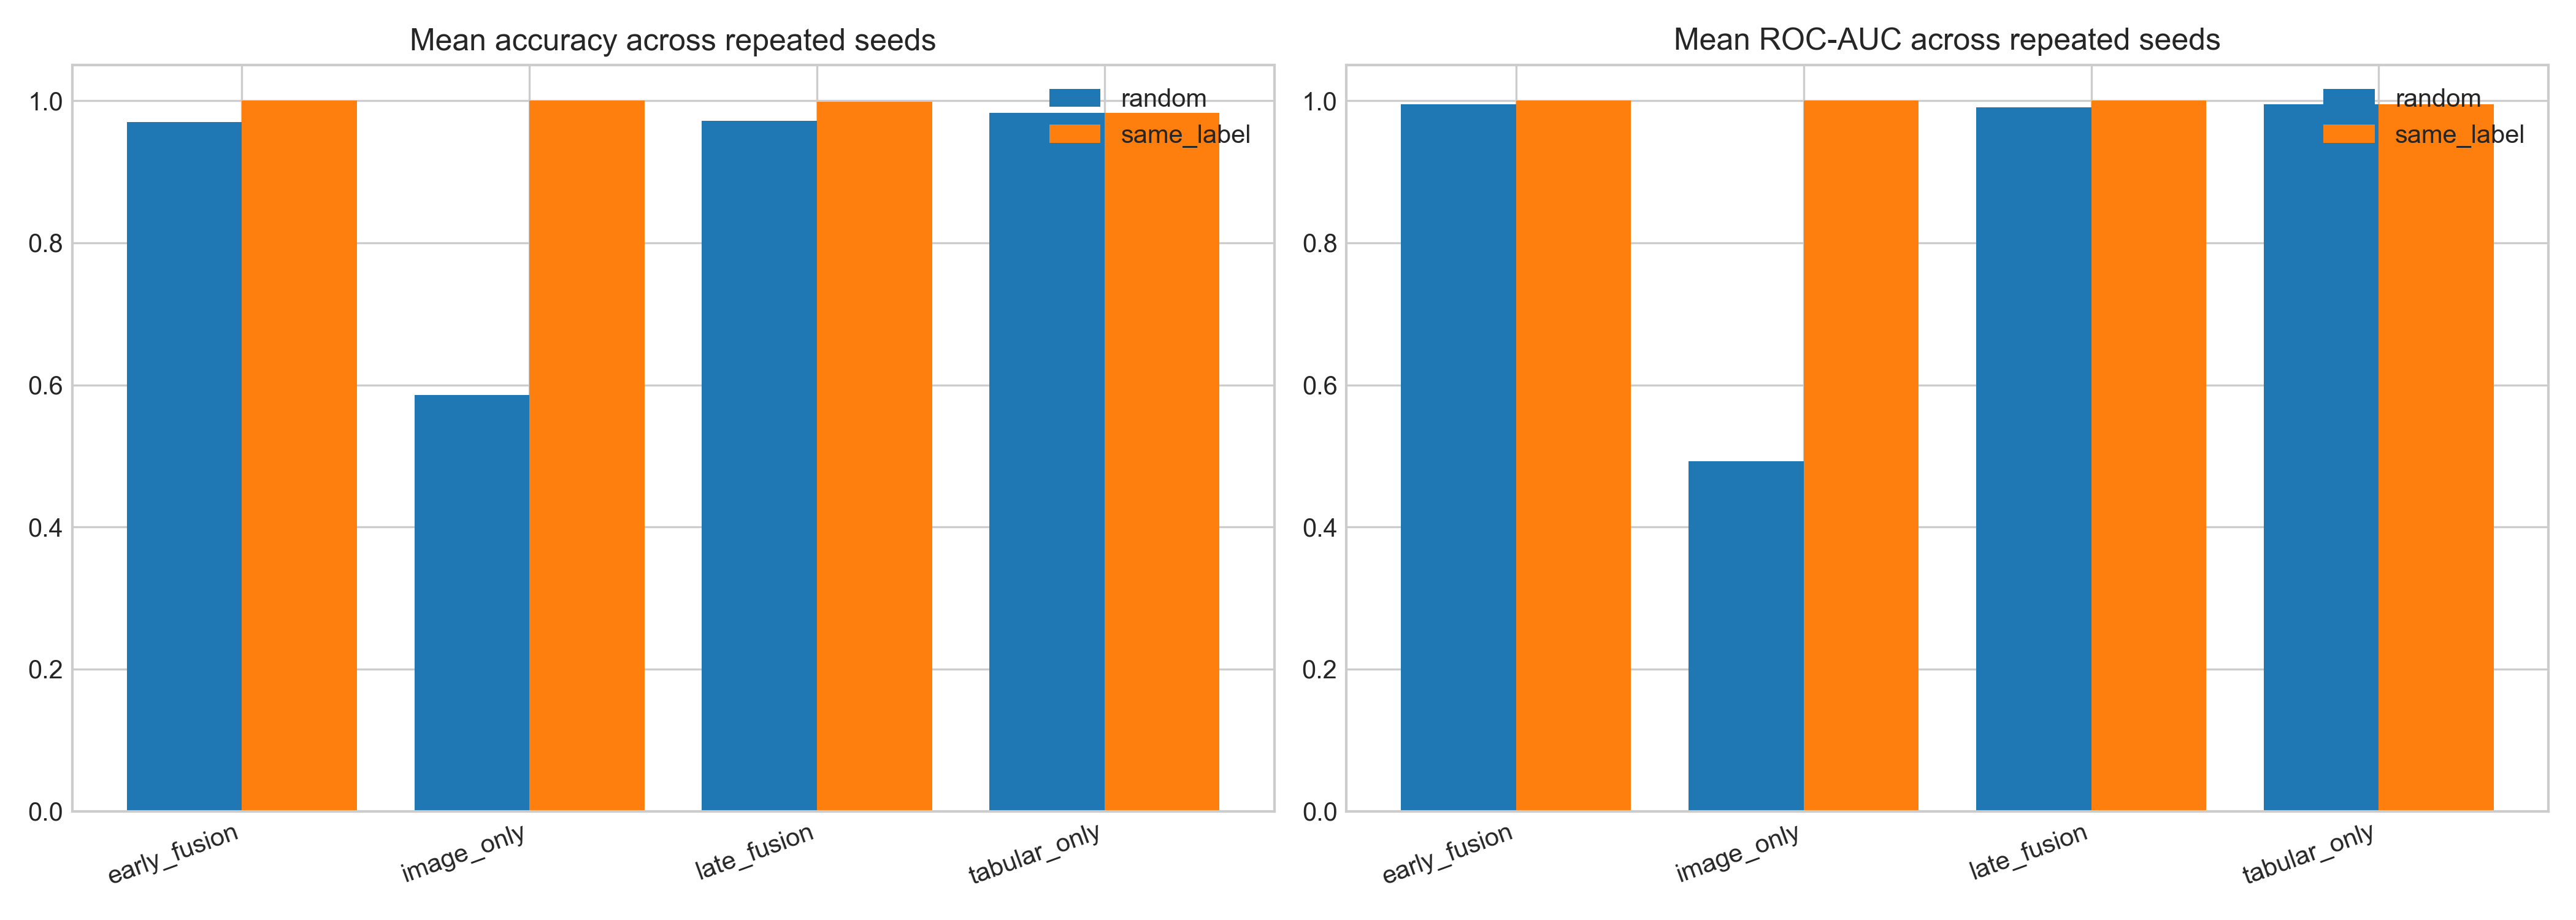


Showing joint_model_accuracy_comparison.png


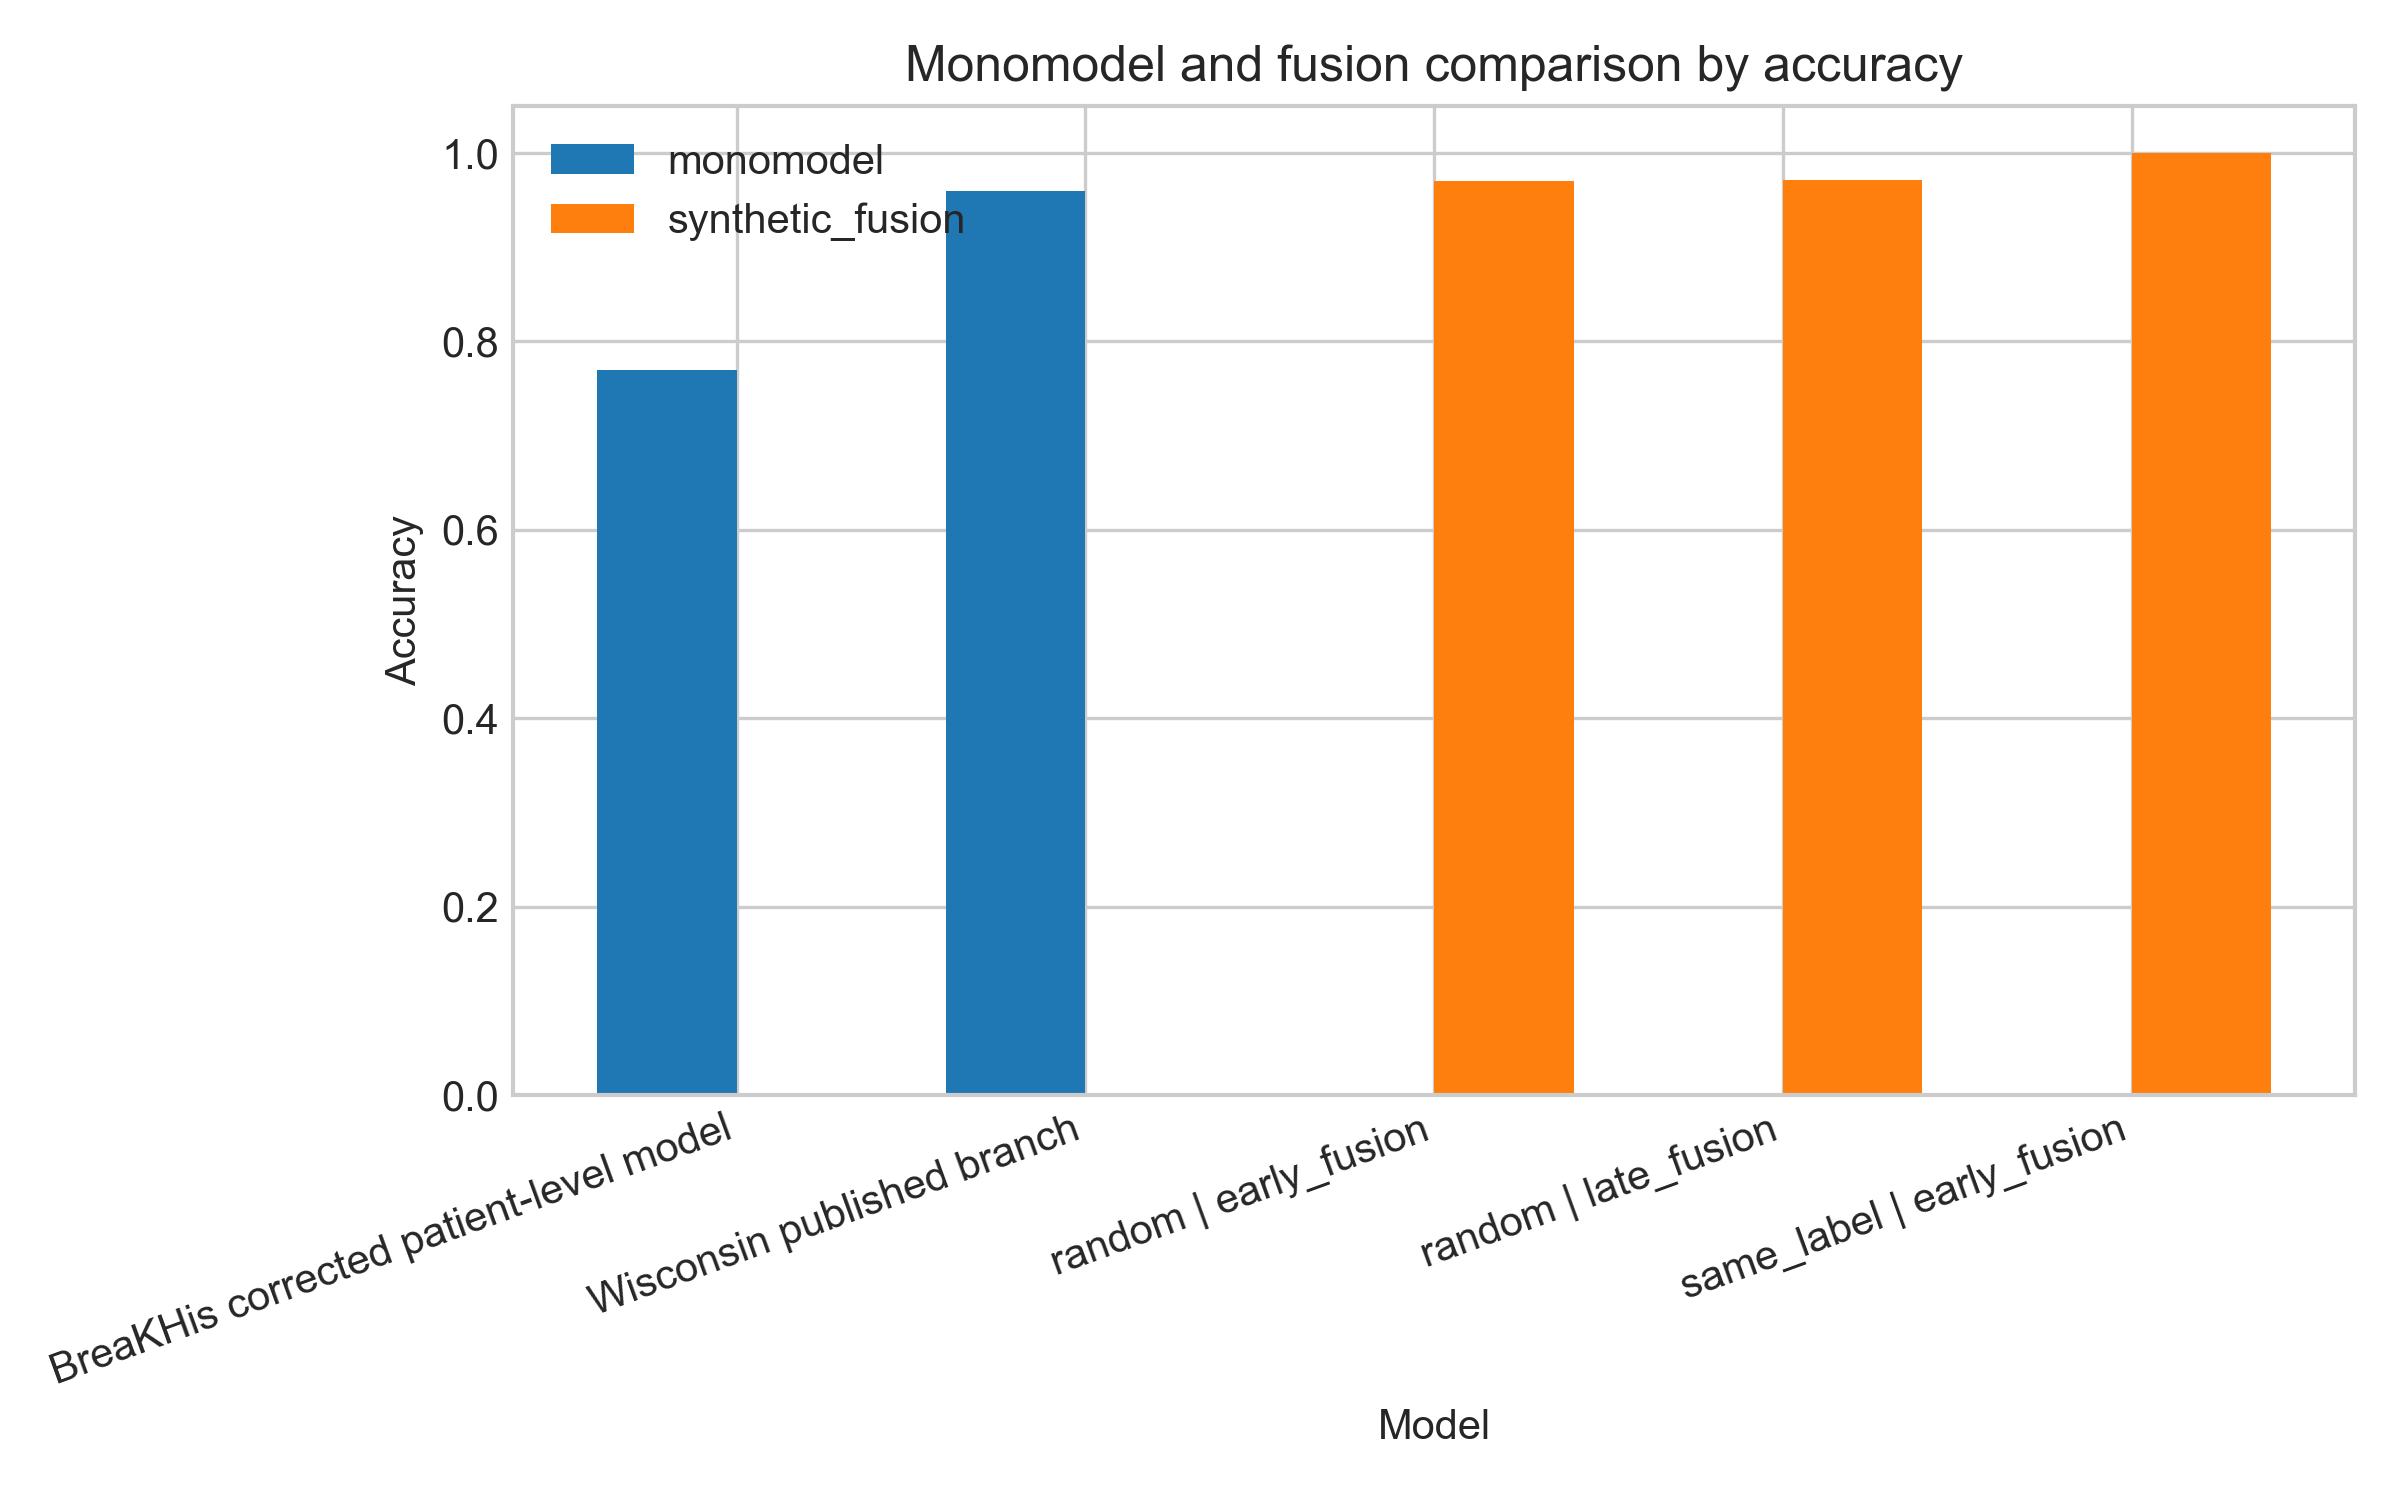

In [4]:
for figure_name in [
    'breakhis_leakage_audit.png',
    'breakhis_patient_confusion_matrix.png',
    'fusion_experiment_comparison.png',
    'joint_model_accuracy_comparison.png',
]:
    print('\nShowing', figure_name)
    display(Image(filename=str(FIGURES / figure_name)))


## Final Position

What this study does show is that correcting the BreaKHis split changes the image story quite a lot, and that the cleaned-up image branch still gives me useful calibration and error-analysis material to discuss. It also shows that the Wisconsin model can be reused unchanged as a strong tabular comparator. What it does not show is a clinically valid multimodal gain from matched patient data, because the pairing is artificial. That distinction matters, and being explicit about it is part of the value of the project rather than a weakness to hide.


## How This Notebook Supports The Dissertation

This notebook is the final packaging layer. It turns the experimental workflow into a defendable research story: what was shown, what was only exploratory, and which figures support each claim.
